# Notebook 02 — Closed-Form Approximations vs Exact ODE

**Figures reproduced**: 
- 2–5 (IG index, $\sigma$ (normal),Bid, ask, spread, skew — exact (×) vs approx (—)), 
- 6-7 (IG index, $\sigma / 2$, Same but approx improves dramatically)
- 10–14 (HY index, $\sigma$ (normal), Same overlay for HY)
- Extension: HY at $\sigma / 2$ (confirms CF quality pattern generalises)



In Notebook 01 we solved the **exact ODE** (Eq. 3.9) numerically and plotted the optimal quotes.
This notebook asks: *can we get those quotes in closed form, without solving any ODE?*


## Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.params.assets import IG, HY, GAMMA, T
from market_making.core.solver_1d import solve_general, solve_model_a
from market_making.core.closed_form import approx_quotes, approx_spread, approx_skew
from market_making.core.intensity import C_coeff

plt.style.use("seaborn-v0_8")
%matplotlib inline

## 0. The closed-form approximation 

In the asymptotic regime ($t \ll T$), the solution simplifies to:

$$\delta^{b*}_{\text{approx}}(n) = \delta_{\text{static}} + \omega \cdot \frac{(2n+1)\Delta}{2}$$
$$\delta^{a*}_{\text{approx}}(n) = \delta_{\text{static}} - \omega \cdot \frac{(2n-1)\Delta}{2}$$

where:

| Symbol | Formula | Role |
|--------|---------|------|
| $\delta_{\text{static}}$ | $\frac{1}{\xi\Delta}\ln\!\left(1 + \frac{\xi\Delta}{k}\right)$ | **Static half-spread** — the quote when inventory doesn't matter |
| $\omega$ | $\sqrt{\dfrac{\gamma\sigma^2}{2\,H''_\xi(0)}} = \sqrt{\dfrac{\gamma\sigma^2}{2\,A\Delta k\,C_\xi}}$ | **Dynamic slope** — how fast quotes tilt with inventory |

And:

$$\text{Spread}_{\text{approx}} = \delta^b + \delta^a = 2\,\delta_{\text{static}} + \omega\Delta \qquad \text{(constant in } n \text{)}$$
$$\text{Skew}_{\text{approx}} = \delta^b - \delta^a = 2n \cdot \omega\Delta \qquad \text{(linear in } n \text{)}$$

## 3. Parameters and intermediate quantities

We use the same IG / HY parameters as Notebook 01 (Paper §6, p. 31), plus a variant with $\sigma_{\text{IG}} / 2$.

The closed-form formulas depend on two intermediate quantities ($\delta_{\text{static}}$ and $\omega$), so let's compute and inspect them explicitly.


In [4]:
# ── Build the four parameter sets ──
IG_half = {**IG, "sigma": IG["sigma"] / 2}  # Paper Figs 6–7
HY_half = {**HY, "sigma": HY["sigma"] / 2}  # Extension: same analysis for HY

configs = [
    ("IG (σ)",   IG),
    ("IG (σ/2)", IG_half),
    ("HY (σ)",   HY),
    ("HY (σ/2)", HY_half),
]

print(f"{'Config':<12s}  {'σ':>12s}  {'ξΔ':>8s}  {'δ_static':>12s}  {'ω':>12s}  "
      f"{'Spread_cf':>12s}  {'Skew(n=3)_cf':>14s}")
print("─" * 92)

for label, p in configs:
    xi_Delta = GAMMA * p["Delta"]
    
    # δ_static  (Eq. 4.6 / 4.7 — the constant term)
    d_static = (1.0 / xi_Delta) * np.log(1.0 + xi_Delta / p["k"])
    
    # ω  (Eq. 4.3 applied to exponential case)
    C = C_coeff(xi_Delta, p["k"])
    omega = np.sqrt(GAMMA * p["sigma"]**2 / (2.0 * p["A"] * p["Delta"] * p["k"] * C))
    
    # Spread and skew from Eqs. 4.8–4.9
    spread = 2 * d_static + omega * p["Delta"]
    skew_3 = 2 * 3 * omega * p["Delta"]
    
    print(f"{label:<12s}  {p['sigma']:>12.2e}  {xi_Delta:>8.0f}  {d_static:>12.6e}  {omega:>12.6e}  "
          f"{spread:>12.6e}  {skew_3:>14.6e}")

Config                   σ        ξΔ      δ_static             ω     Spread_cf    Skew(n=3)_cf
────────────────────────────────────────────────────────────────────────────────────────────
IG (σ)            5.83e-06      3000  5.164948e-05  1.919561e-12  1.992770e-04    5.758682e-04
IG (σ/2)          2.92e-06      3000  5.164948e-05  9.597803e-13  1.512880e-04    2.879341e-04
HY (σ)            2.15e-05       600  1.734666e-04  2.618159e-11  6.087492e-04    1.570896e-03
HY (σ/2)          1.08e-05       600  1.734666e-04  1.309080e-11  4.778413e-04    7.854478e-04


## 5. Solve exact ODE (Eq. 3.9, Model A)

We need the exact solution as the reference against which to compare the closed-form formulas. Same solver as Notebook 01 (`solve_general`, Newton on implicit Euler, $N_t = 7200$).


In [19]:
N_T = 7200

# Solving IG — Model A (σ normal) 
#Done in 3.3s
sol_ig = solve_model_a(IG, GAMMA, T, N_t=N_T)

In [20]:
# Solving IG — Model A (σ/2)
sol_ig_half = solve_model_a(IG_half, GAMMA, T, N_t=N_T)

In [21]:
# Solving HY — Model A (σ normal)
sol_hy = solve_model_a(HY, GAMMA, T, N_t=N_T)

In [22]:
# Solving HY — Model A (σ/2)
sol_hy_half = solve_model_a(HY_half, GAMMA, T, N_t=N_T)

## 6. Quantitative comparison: approximation error

Before plotting, let's measure the error numerically. This quantifies the paper's qualitative statements about when the approximation is *"satisfactory"* vs *"more questionable"* (p. 33).


In [23]:
def error_report(sol, params, label):
    """Compute max/mean absolute and relative errors between exact and approx."""
    Q = int(params["Q"])
    n_arr = np.arange(-Q + 1, Q)
    
    db_cf, da_cf = approx_quotes(n_arr, params, GAMMA, xi=GAMMA)
    
    # Exact values at t=0, restricted to the same n range
    # n_arr maps to indices [1, ..., 2Q-1] in the lots array
    idx = np.array([int(n + Q) for n in n_arr])
    db_ex = sol["delta_bid"][0, idx]
    da_ex = sol["delta_ask"][0, idx]
    
    # Filter out NaNs (boundaries)
    mask_b = np.isfinite(db_ex)
    mask_a = np.isfinite(da_ex)
    
    for side, ex, cf, mask in [("Bid", db_ex, db_cf, mask_b), ("Ask", da_ex, da_cf, mask_a)]:
        abs_err = np.abs(ex[mask] - cf[mask])
        rel_err = abs_err / np.abs(ex[mask])
        print(f"  {label} {side}:  max|err| = {abs_err.max():.3e}  "
              f" mean|err| = {abs_err.mean():.3e}  "
              #f" max rel = {rel_err.max():.1%}  "
              #f" mean rel = {rel_err.mean():.1%}"
              )

print("─" * 70)
error_report(sol_ig, IG, "IG (σ)  ")
print("─" * 70)
error_report(sol_ig_half, IG_half, "IG (σ/2)")
print("─" * 70)
error_report(sol_hy, HY, "HY (σ)  ")
print("─" * 70)
error_report(sol_hy_half, HY_half, "HY (σ/2)")
print("─" * 70)

──────────────────────────────────────────────────────────────────────
  IG (σ)   Bid:  max|err| = 1.199e-04   mean|err| = 4.007e-05  
  IG (σ)   Ask:  max|err| = 1.199e-04   mean|err| = 4.007e-05  
──────────────────────────────────────────────────────────────────────
  IG (σ/2) Bid:  max|err| = 2.480e-05   mean|err| = 8.101e-06  
  IG (σ/2) Ask:  max|err| = 2.480e-05   mean|err| = 8.101e-06  
──────────────────────────────────────────────────────────────────────
  HY (σ)   Bid:  max|err| = 2.741e-04   mean|err| = 8.800e-05  
  HY (σ)   Ask:  max|err| = 2.741e-04   mean|err| = 8.800e-05  
──────────────────────────────────────────────────────────────────────
  HY (σ/2) Bid:  max|err| = 4.655e-05   mean|err| = 1.569e-05  
  HY (σ/2) Ask:  max|err| = 4.655e-05   mean|err| = 1.569e-05  
──────────────────────────────────────────────────────────────────────


Expected: σ/2 errors << σ errors 

## 7. Figures 2–5 (IG, $\sigma$ normal) — Exact vs Closed-Form

**Paper reference** (p. 32–33):
- **Fig 2**: $q_{\text{IG}} \mapsto \delta^{b,*}(0, q_{\text{IG}})$ — crosses (exact) + line (Eq. 4.6)
- **Fig 3**: $q_{\text{IG}} \mapsto \delta^{a,*}(0, q_{\text{IG}})$ — crosses (exact) + line (Eq. 4.7)
- **Fig 4**: Spread — crosses (exact) + line (Eq. 4.8)
- **Fig 5**: Skew — crosses (exact) + line (Eq. 4.9)

> *"The closed-form approximations are satisfactory for small values of the inventory (in absolute value), but more questionable for larger values. In particular, the optimal quotes are not affine functions of the inventory."* — p. 33


In [24]:
def overlay_plots(sol, params, label, sigma_label,
                  fig_bid=None, fig_ask=None, fig_spread=None, fig_skew=None):
    """
    Plot exact ODE solution vs closed-form approximation
    for bid, ask, spread, and skew at t = 0.
    """

    Q = int(params["Q"])
    lots = sol["lots"]

    # Interior inventory grid used in the paper overlays: n = -Q+1, ..., Q-1
    n_arr = np.arange(-Q + 1, Q)

    # Closed-form approximation
    db_cf, da_cf = approx_quotes(n_arr, params, GAMMA, xi=GAMMA)
    spread_cf = db_cf + da_cf
    skew_cf = db_cf - da_cf

    # Exact ODE values at the same inventory points
    idx = np.array([np.where(lots == n)[0][0] for n in n_arr])

    db_exact = sol["delta_bid"][0, idx]
    da_exact = sol["delta_ask"][0, idx]
    spread_exact = db_exact + da_exact
    skew_exact = db_exact - da_exact

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ─────────────────────────────
    # 1) Bid
    # ─────────────────────────────
    ax = axes[0, 0]
    ax.scatter(n_arr, db_exact, s=70, marker="x", linewidths=2.0,
               color="C0", label="Exact (ODE, Eq. 3.9)", zorder=4)
    ax.plot(n_arr, db_cf, "-", lw=2.2, color="C2",
            label="Approx (Eq. 4.6)", zorder=2)
    title = f"{label} ({sigma_label}) — δ^bid(0, n)"
    if fig_bid is not None:
        title = f"Fig {fig_bid}: {title}"
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^bid ($/upfront)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

    # ─────────────────────────────
    # 2) Ask
    # ─────────────────────────────
    ax = axes[0, 1]
    ax.scatter(n_arr, da_exact, s=55, marker="o",
               color="C0", label="Exact (ODE, Eq. 3.9)", zorder=4)
    ax.plot(n_arr, da_cf, "-", lw=2.2, color="C2",
            label="Approx (Eq. 4.7)", zorder=2)
    title = f"{label} ({sigma_label}) — δ^ask(0, n)"
    if fig_ask is not None:
        title = f"Fig {fig_ask}: {title}"
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^ask ($/upfront)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

    # ─────────────────────────────
    # 3) Spread
    # ─────────────────────────────
    ax = axes[1, 0]
    ax.scatter(n_arr, spread_exact, s=55, marker="s",
               color="C0", label="Exact", zorder=4)
    ax.plot(n_arr, spread_cf, "-", lw=2.2, color="C2",
            label="Approx (Eq. 4.8 → constant)", zorder=2)
    title = f"{label} ({sigma_label}) — Spread(0, n)"
    if fig_spread is not None:
        title = f"Fig {fig_spread}: {title}"
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^b + δ^a ($/upfront)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

    # ─────────────────────────────
    # 4) Skew
    # ─────────────────────────────
    ax = axes[1, 1]
    ax.scatter(n_arr, skew_exact, s=60, marker="D",
               color="C0", label="Exact", zorder=4)
    ax.plot(n_arr, skew_cf, "-", lw=2.2, color="C2",
            label="Approx (Eq. 4.9 → linear)", zorder=2)
    ax.axhline(0.0, color="gray", ls=":", lw=0.8)
    title = f"{label} ({sigma_label}) — Skew(0, n)"
    if fig_skew is not None:
        title = f"Fig {fig_skew}: {title}"
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^b − δ^a ($/upfront)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

    fig.suptitle(f"Closed-form (§4) vs exact ODE (§3) — {label} ({sigma_label})",
                 fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

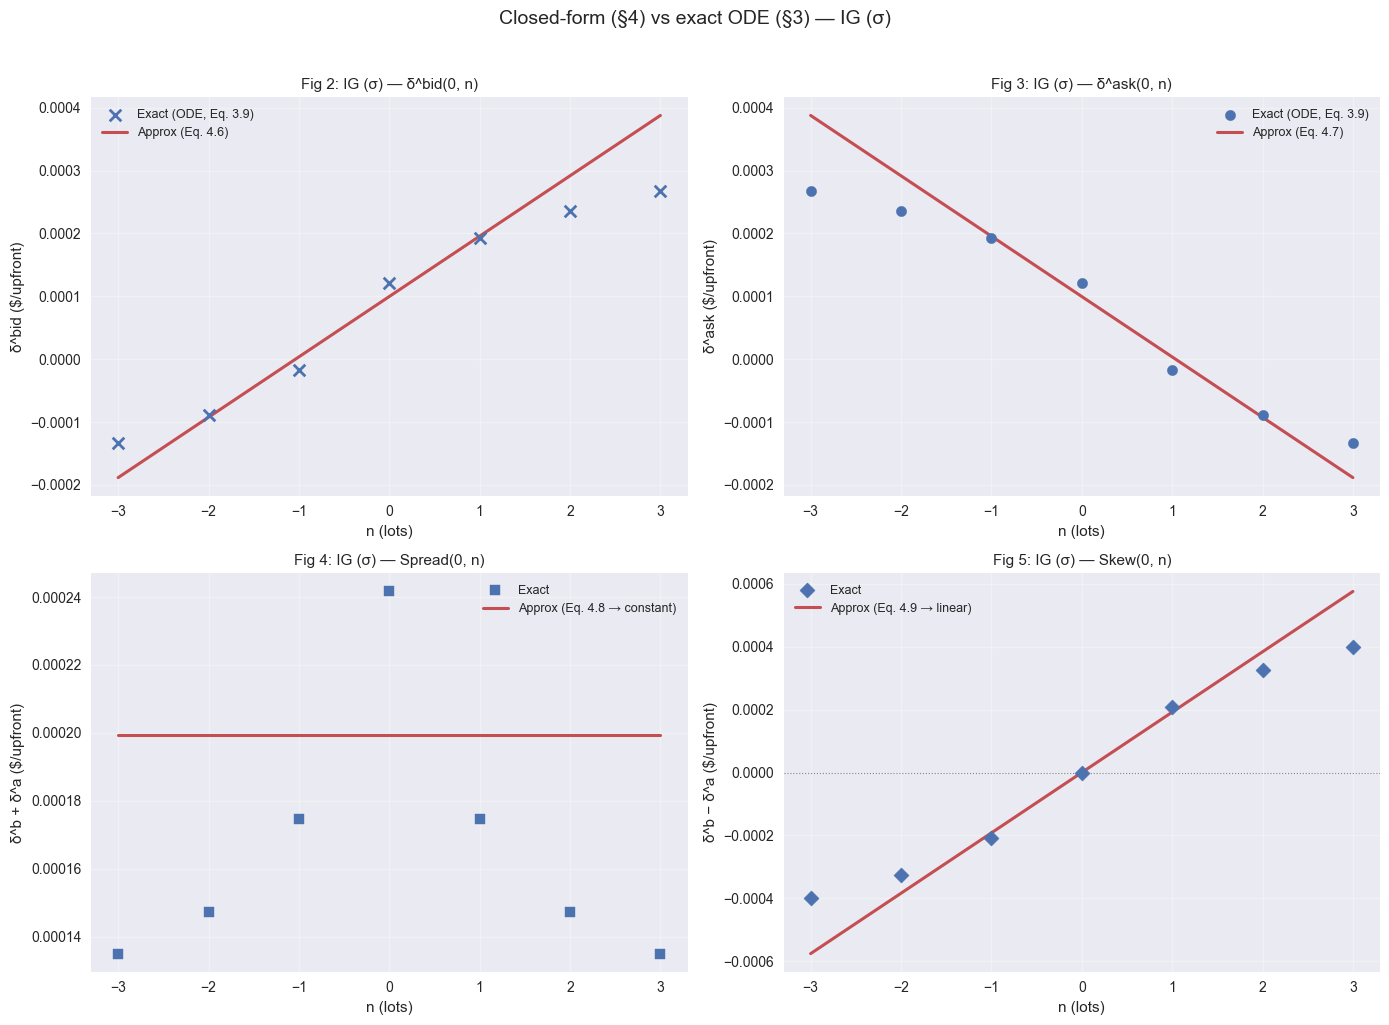

In [25]:
overlay_plots(sol_ig, IG, "IG", "σ", fig_bid=2, fig_ask=3, fig_spread=4, fig_skew=5)

The plots reproduce the qualitative message of Figures 2 to 5. The closed-form approximation is reasonably accurate near zero inventory, but it deviates visibly at the boundaries. In particular, the exact spread is not constant and the exact skew is not perfectly linear, confirming the paper’s statement that the optimal quotes are not affine in inventory.

## 8. Figures 6–7 (IG, $\sigma / 2$) — Approximation improves at low volatility

**Paper reference** (p. 34):
> *"If we consider market conditions with less volatility, then the closed-form approximations are far better — see Figures 6 and 7 where we computed the optimal bid and ask quotes (in Model A) for a value of $\sigma_{\text{IG}}$ divided by 2."*

**Why does halving $\sigma$ help?**

The dynamic slope $\omega \propto \sigma$, so halving $\sigma$ halves $\omega$. This means:
- The inventory-dependent part of the quote ($\omega \cdot n \cdot \Delta$) becomes smaller.
- $\theta(t, q)$ is flatter → the Taylor expansion (which assumed $\Delta$ is "small") becomes more accurate.
- Effectively, the ratio of the inventory penalty ($\frac{1}{2}\gamma\sigma^2 q^2$) to the fill benefit ($H_\xi$) shrinks, bringing us closer to the regime where the continuous PDE approximation is valid.

The paper only shows Figs 6–7 (bid + ask); we include spread and skew as well.


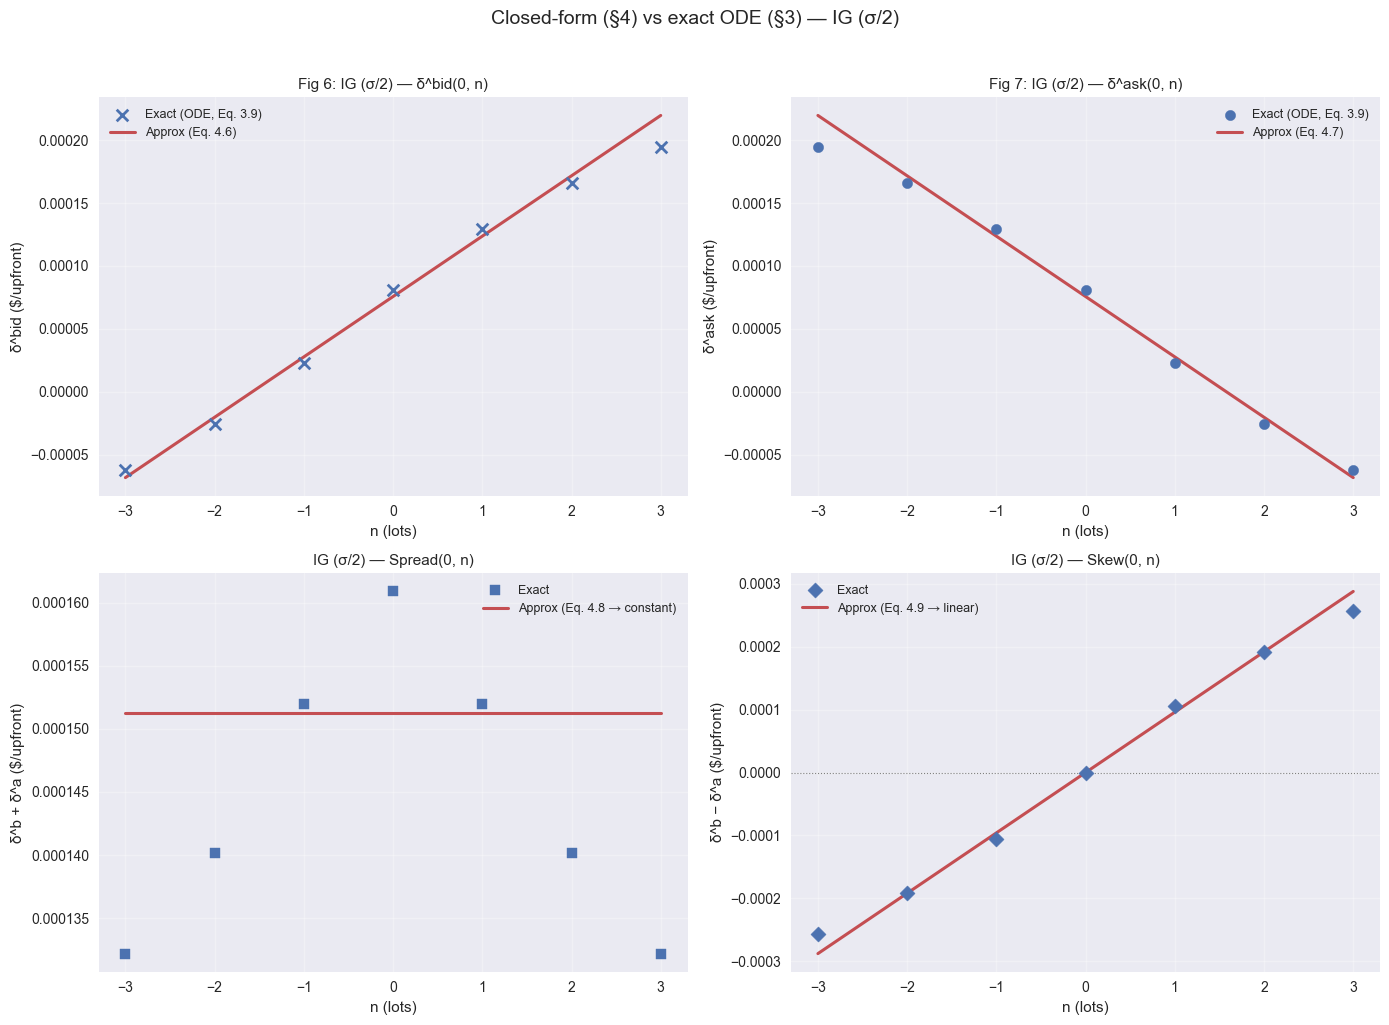

In [26]:
overlay_plots(sol_ig_half, IG_half, "IG", "σ/2", fig_bid=6, fig_ask=7)

When volatility is divided by two, the approximation improves markedly. This is exactly the phenomenon reported in Figures 6 and 7 of the paper: lower volatility reduces the inventory-risk component of the quotes, which makes the first-order asymptotic approximation much more accurate.

## 9. Figures 11–14 (HY, $\sigma$ normal) — Same analysis for the HY index

**Paper reference** (p. 37):
> *"We also see that the closed-form approximations are satisfactory only for small values of the inventory (in absolute value)."*

The HY index has:
- **Higher $\sigma$** ($2.15 \times 10^{-5}$ vs $5.83 \times 10^{-6}$) → stronger inventory penalty.
- **Smaller $\Delta$** ($10$M vs $50$M) → smaller ξΔ = 600 (vs 3000 for IG).
- **Smaller $k$** ($5.47 \times 10^3$ vs $1.79 \times 10^4$) → fills less sensitive to spread.

The net effect: $\omega_{\text{HY}} \gg \omega_{\text{IG}}$ (we can verify below), so the approximation error should be larger for HY.


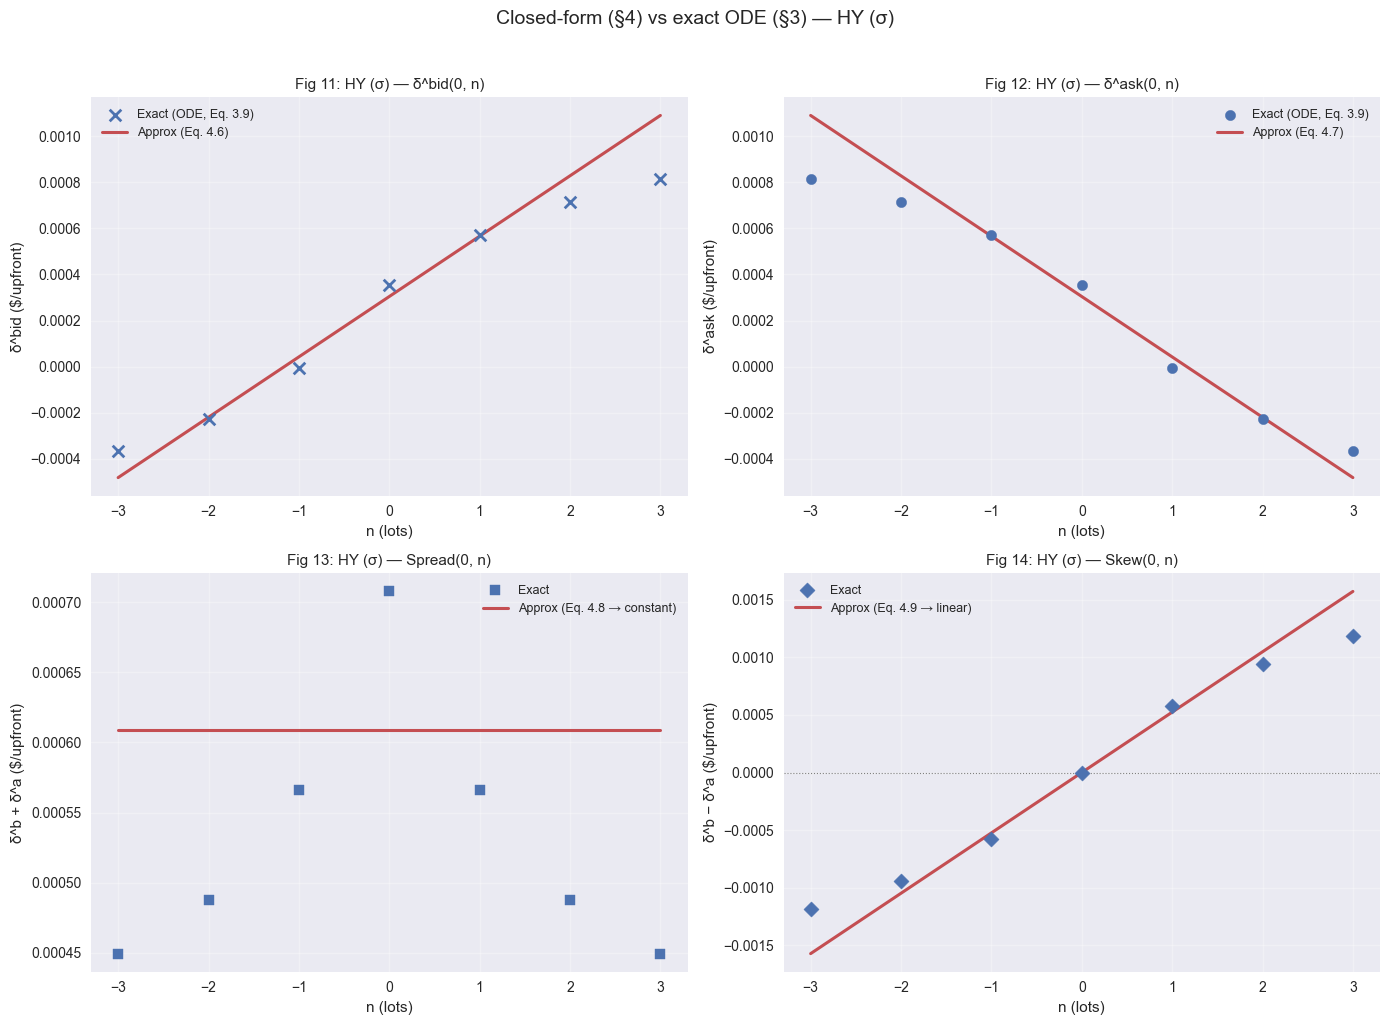

In [27]:
overlay_plots(sol_hy, HY, "HY", "σ", fig_bid=11, fig_ask=12, fig_spread=13, fig_skew=14)

The HY case reproduces the same pattern as Figures 11 to 14. The approximation is acceptable near zero inventory but deteriorates at larger inventories. The exact spread is curved rather than constant, and the exact skew is increasing but clearly non-linear.

## 10. HY at $\sigma / 2$ — Confirming the approximation quality pattern

The paper only shows Figs 6–7 (IG at σ/2). We extend this analysis to HY.

**Prediction**: HY already has a smaller ξΔ = 600 (vs 3000 for IG), so the CF is already
a good approximation at full σ. At σ/2, we expect it to become **near-exact**.

This confirms the general principle: **the closed-form quality depends on ξΔ and ω, not on
the asset itself**. When ω is small (low σ or small Δ), the inventory-dependent corrections
are small and the linear approximation (Eqs. 4.6–4.9) is excellent.


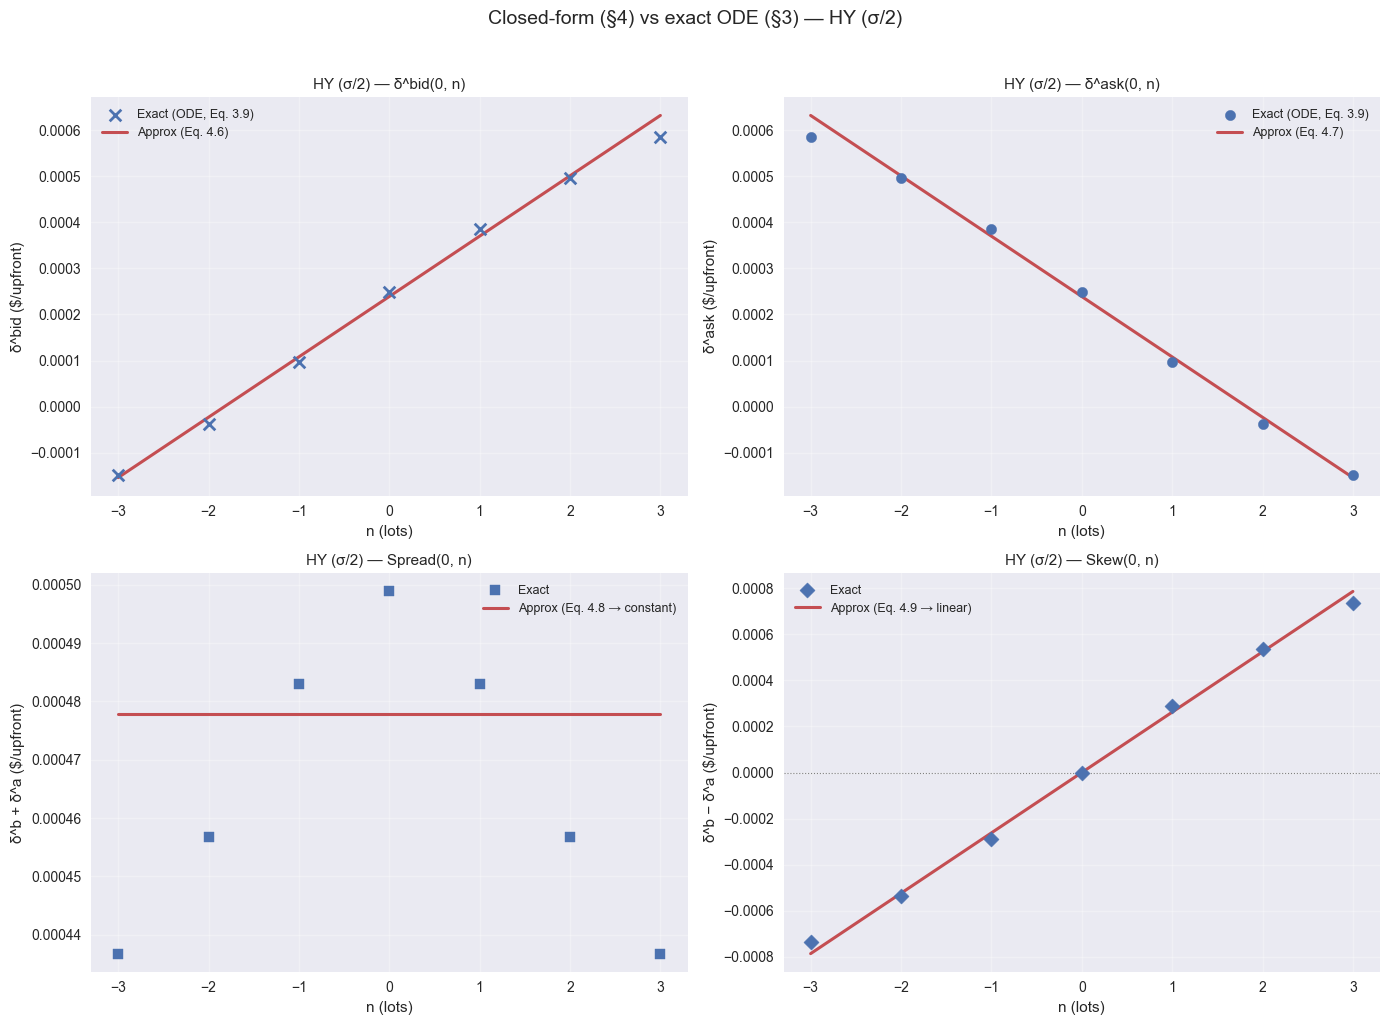

In [28]:
overlay_plots(sol_hy_half, HY_half, "HY", "σ/2")

This is an extension beyond the paper. Halving volatility makes the closed-form approximation almost exact on the central inventory range, which confirms that approximation quality depends mainly on the strength of the inventory-risk term rather than on the asset label itself.

In [29]:
def error_summary(sol, params, label):
    Q = int(params["Q"])
    n_arr = np.arange(-Q + 1, Q)
    idx = np.array([int(n + Q) for n in n_arr])

    db_cf, da_cf = approx_quotes(n_arr, params, GAMMA, xi=GAMMA)
    db_ex = sol["delta_bid"][0, idx]
    da_ex = sol["delta_ask"][0, idx]

    spread_ex = db_ex + da_ex
    spread_cf = db_cf + da_cf
    skew_ex = db_ex - da_ex
    skew_cf = db_cf - da_cf

    def stats(x, y):
        abs_err = np.abs(x - y)
        return abs_err.max(), abs_err.mean()

    bid_max, bid_mean = stats(db_ex, db_cf)
    ask_max, ask_mean = stats(da_ex, da_cf)
    spr_max, spr_mean = stats(spread_ex, spread_cf)
    skw_max, skw_mean = stats(skew_ex, skew_cf)

    print(f"\n=== {label} ===")
    print(f"Bid    : max = {bid_max:.3e}, mean = {bid_mean:.3e}")
    print(f"Ask    : max = {ask_max:.3e}, mean = {ask_mean:.3e}")
    print(f"Spread : max = {spr_max:.3e}, mean = {spr_mean:.3e}")
    print(f"Skew   : max = {skw_max:.3e}, mean = {skw_mean:.3e}")

In [30]:
error_summary(sol_ig, IG, "IG (σ)")
error_summary(sol_ig_half, IG_half, "IG (σ/2)")
error_summary(sol_hy, HY, "HY (σ)")
error_summary(sol_hy_half, HY_half, "HY (σ/2)")


=== IG (σ) ===
Bid    : max = 1.199e-04, mean = 4.007e-05
Ask    : max = 1.199e-04, mean = 4.007e-05
Spread : max = 6.431e-05, mean = 4.636e-05
Skew   : max = 1.755e-04, mean = 7.206e-05

=== IG (σ/2) ===
Bid    : max = 2.480e-05, mean = 8.101e-06
Ask    : max = 2.480e-05, mean = 8.101e-06
Spread : max = 1.910e-05, mean = 1.020e-05
Skew   : max = 3.049e-05, mean = 1.171e-05

=== HY (σ) ===
Bid    : max = 2.741e-04, mean = 8.800e-05
Ask    : max = 2.741e-04, mean = 8.800e-05
Spread : max = 1.595e-04, mean = 1.066e-04
Skew   : max = 3.887e-04, mean = 1.579e-04

=== HY (σ/2) ===
Bid    : max = 4.655e-05, mean = 1.569e-05
Ask    : max = 4.655e-05, mean = 1.569e-05
Spread : max = 4.106e-05, mean = 2.223e-05
Skew   : max = 5.205e-05, mean = 2.523e-05


## 11. Bonus: Decomposing the spread into static and dynamic components

The closed-form spread (Eq. 4.8) has two parts:

$$\text{Spread} = \underbrace{2\,\delta_{\text{static}}}_{\text{compensation for adverse selection}} + \underbrace{\omega \cdot \Delta}_{\text{compensation for inventory risk}}$$

Let's visualise the relative weight of each component.


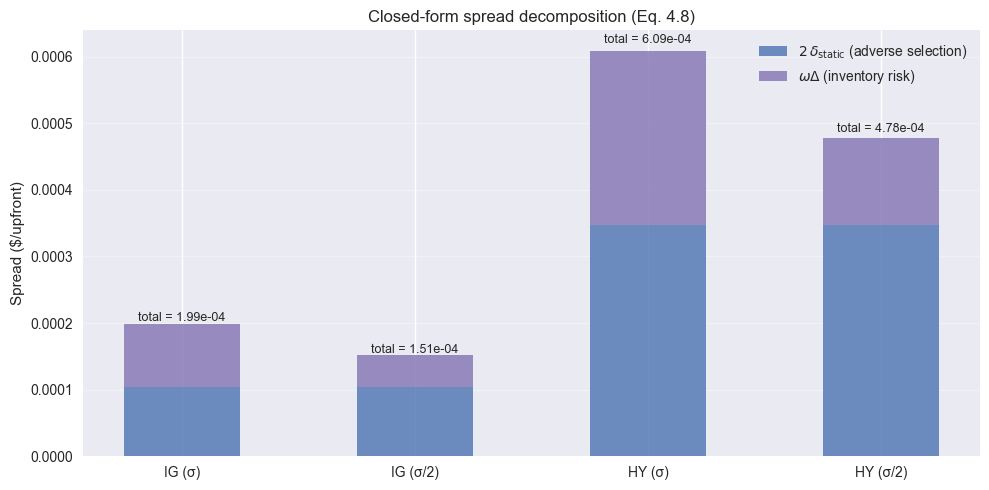

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_data = []
for label, p in [("IG (σ)", IG), ("IG (σ/2)", IG_half), ("HY (σ)", HY), ("HY (σ/2)", HY_half)]:
    xi_Delta = GAMMA * p["Delta"]
    d_static = (1.0 / xi_Delta) * np.log(1.0 + xi_Delta / p["k"])
    C = C_coeff(xi_Delta, p["k"])
    omega = np.sqrt(GAMMA * p["sigma"]**2 / (2.0 * p["A"] * p["Delta"] * p["k"] * C))
    
    static_part = 2 * d_static
    dynamic_part = omega * p["Delta"]
    bar_data.append((label, static_part, dynamic_part))

labels = [d[0] for d in bar_data]
statics = [d[1] for d in bar_data]
dynamics = [d[2] for d in bar_data]

x = np.arange(len(labels))
w = 0.5
ax.bar(x, statics, w, label=r"$2\,\delta_{\mathrm{static}}$ (adverse selection)", color="C0", alpha=0.8)
ax.bar(x, dynamics, w, bottom=statics, label=r"$\omega\Delta$ (inventory risk)", color="C3", alpha=0.8)

for i, (s, d) in enumerate(zip(statics, dynamics)):
    ax.text(i, s + d + (s+d)*0.02, f"total = {s+d:.2e}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Spread ($/upfront)")
ax.set_title("Closed-form spread decomposition (Eq. 4.8)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()



The numerical results confirm the main message of Section 4 of the paper.
Closed-form formulas provide a useful approximation of the optimal quotes in the asymptotic regime, but their accuracy is mainly local in inventory. They work well around n=0, where the exact value function is close to its quadratic approximation, but they become less reliable near the inventory boundaries.
Reducing volatility improves the approximation substantially, because it reduces the inventory-risk contribution to the quotes. This is consistent with the paper’s IG experiment with σ/2, and our HY extension shows that the same mechanism carries over beyond the examples explicitly reported in the article.